In [2]:
import numpy as np
import matplotlib.pyplot as plt

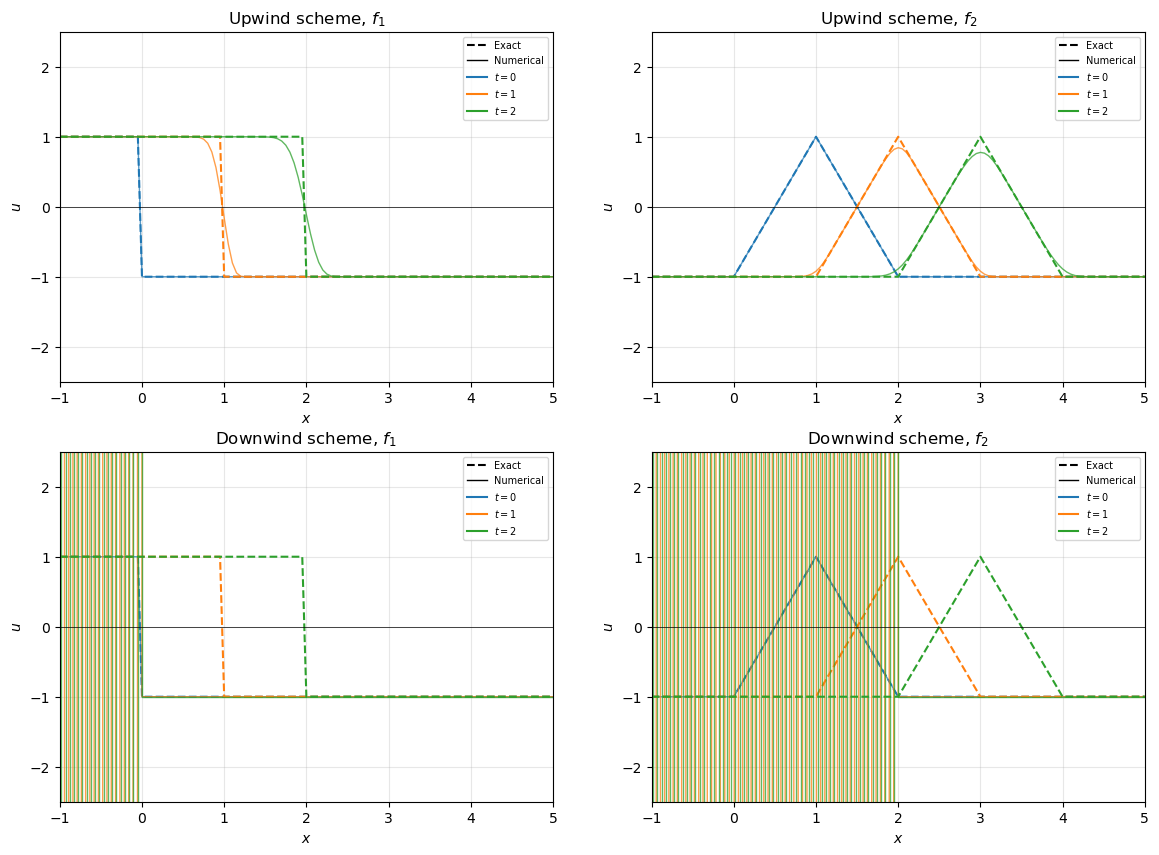

In [17]:
# --- Parameters for this problem ---
h = 0.05
k = 0.04
c = 1.0    # This is an assumption; it's not given in the problem, so we'll go with this
lam = k / h
t_end = 2.0

# --- Create a grid ---
x = np.arange(-1, 5 + h, h)

# --- Calculate the number of timesteps ---
n_steps = int(round(t_end / k))

# --- Specify the times at which to plot curves ---
plot_times = [0, 1, 2]
plot_steps = [int(round(t / k)) for t in plot_times]

# --- DEFINE FUNCTIONS FOR INITIAL DATA ---
def f1(x):
  return np.where(x < 0, 1.0, np.where(x == 0, 0.0, -1.0))

def f2(x):
  return np.where(x < 0, -1.0, np.where(x <= 2, 1 - 2*np.abs(x-1), -1.0))

# --- DEFINE THE EXACT SOLUTION ---
def exact(f, x, t):
  # The solution is constant along the lines x-ct = constant, so
  return f(x - c*t)

# --- DEFINE UPWIND AND DOWNWIND SCHEMES ---
def upwind(f, x, n_steps, plot_steps):
  # Initialize the numerical solution as an array of floats
  u = f(x).astype(float)
  # Create a dictionary of the information from the snapshots
  snapshots = {}
  if 0 in plot_steps:
    # Save the initial condition if t = 0 is one of our plot times
    snapshots[0] = u.copy()

  # Iterate over each timestep
  for n in range(1, n_steps+1):
    # Make a copy so we don't overwrite values we still need in this step
    u_new = u.copy()
    # Upwind: backward difference (c > 0)
    u_new[1:] = u[1:] - c * lam * (u[1:] - u[:-1])
    # At left boundary, there is no j-1 point, so keep it constant
    u_new[0] = u[0]
    u = u_new         # Update u for the next step

    # If this is a time step we want to plot, then save the information
    if n in plot_steps:
      snapshots[n] = u.copy()

  return snapshots

def downwind(f, x, n_steps, plot_steps):
  u = f(x).astype(float)
  snapshots = {}
  if 0 in plot_steps:
    snapshots[0] = u.copy()

  for n in range(1, n_steps+1):
    u_new = u.copy()
    # Downwind: forward difference
    u_new[:-1] = u[:-1] - c * lam * (u[1:] - u[:-1])
    # The problematic boundary is now the right-hand boundary (also why we need to use u_new[:-1] above)
    u_new[-1] = u[-1]
    u = u_new

    if n in plot_steps:
      snapshots[n] = u.copy()

  return snapshots

# --- CREATE THE FIGURE ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scheme_names = ['Upwind', 'Downwind']
scheme_funcs = [upwind, downwind]
initial_funcs = [f1, f2]
func_names = ['$f_1$', '$f_2$']

for col, (f, fname) in enumerate(zip(initial_funcs, func_names)):
    for row, (scheme_func, sname) in enumerate(zip(scheme_funcs, scheme_names)):
        ax = axes[row][col]
        snapshots = scheme_func(f, x, n_steps, plot_steps)
        colors = ['tab:blue', 'tab:orange', 'tab:green']
        for i, (t_plot, step) in enumerate(zip(plot_times, plot_steps)):
            u_exact = exact(f, x, t_plot)
            ax.plot(x, snapshots[step], color=colors[i], linestyle='-', linewidth=1.0, alpha=0.75)
            ax.plot(x, u_exact, color=colors[i], linestyle='--', linewidth=1.5)
        handles = [
            Line2D([0], [0], color='k', linestyle='--', linewidth=1.5, label='Exact'),
            Line2D([0], [0], color='k', linestyle='-', linewidth=1.0, label='Numerical'),
            Line2D([0], [0], color='tab:blue', linestyle='-', label='$t=0$'),
            Line2D([0], [0], color='tab:orange', linestyle='-', label='$t=1$'),
            Line2D([0], [0], color='tab:green', linestyle='-', label='$t=2$'),
        ]
        ax.legend(handles=handles, fontsize=7)
        ax.set_title(f'{sname} scheme, {fname}')
        ax.set_xlabel('$x$')
        ax.set_ylabel('$u$')
        ax.set_xlim(-1, 5)
        ax.set_ylim(-2.5, 2.5)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.grid(True, alpha=0.3)